# Dark Matter Data Handling with Gammapy

In any dark matter indirect detection analysis, the first step is to define
what data you are going to work with. Gammapy supports two complementary
approaches:

- **Simulated data:** you generate synthetic observations from a theoretical model.

- **Real data:** you load actual telescope observations in DL3 format (check https://docs.gammapy.org/dev/user-guide/package.html for more detail about this data level) and reduce them to a dataset ready for statistical analysis.

In both cases, the analysis is identical in Gammapy, a a pipeline developed on simulations can be directly applied to real data with minimal changes.

Beyond this choice, Gammapy also supports two complementary approaches in terms of analysis geometry:

- **1D (spectral, region-based)**. In **1D**, all spatial information is collapsed into a single region (tipically a circle around the target, with ON/OFF for the background).
- **3D (spatial+spectral, map-based)**. In **3D**, the full spatial distribution across the field of view is kept.

The signal and background models are built in exactly the same way in both cases — only the geometry, the dataset type, and the makers used to fill it change.

**In this tutorial we show the results on the 3D approach, since it is the most complete approach and we will point out the differences with 1D as they appear.**

The different sections in the tutorial are:
- Simulation Dark Matter observations
	- Signal model
		- Spatial model
		- Spectral model
      - How to simulate a signal+background or only background
    -  Sky model
	- Background model
	- IRF and observation setup
	- Dataset
		- Spatial approaches
			- 3D - Spatial+Spectral
			- 1D - Spectral
	- Simulation. From dataset to counts
		- Asimov
		- Monte Carlo
- Real Data management
	- Loading the data
	- Observation selection
	- Dataset reduction
	- From real data to DM analysis
- Data inspection

## Setup

In [85]:
from gammapy.data import Observation, FixedPointingInfo
from gammapy.datasets import MapDataset, SpectrumDataset
from gammapy.irf import load_irf_dict_from_file
from gammapy.makers import (
    MapDatasetMaker,
    SafeMaskMaker,
    SpectrumDatasetMaker
)
from gammapy.maps import MapAxis, WcsGeom, WcsNDMap, RegionGeom
from gammapy.modeling.models import (
    FoVBackgroundModel,
    Models,
    SkyModel,
    PointSpatialModel
)
from gammapy.astro.darkmatter import (
    DarkMatterAnnihilationSpectralModel
)
from regions import CircleSkyRegion

import astropy.units as u
from astropy.coordinates import SkyCoord, EarthLocation, AltAz
from astropy.time import Time
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable


## Simulating Dark Matter observations

To simulate an observation, Gammapy needs a model to predict what the
telescope *should* see, and the IRFs to translate that physical
prediction into observable counts.

### Simulation ingredients
To simulate an observation we need three ingredients:

- **A signal model:** the expected gamma-ray spectrum from DM annihilation or decay, built from the J/D-factor and the particle physics spectrum (see tutorial 'Dark Matter Indirect Detection with Gammapy: Basics').
- **A background model:** the residual cosmic-ray background surviving the gamma/hadron separation cuts.
- **Instrument Response Functions (IRFs):** the telescope's effective area, energy dispersion, and PSF, which translate the physical flux into observable counts.

### Simulation steps

The steps to do this are:

**1. Signal model** — the expected gamma-ray signal from DM annihilation or decay, built from two components:

  - **1.1. Spatial model** — describes the shape and position of the target on the sky (e.g. a point source centered on Draco). This position is used differently depending on the approach: in **3D** it places the source directly on the map; in **1D** it is used only internally, to compute the fraction of the PSF contained within the chosen ON region. Either way, the model is built the same way — only how it's *used* downstream differs.


  - **1.2. Spectral model** — describes how much gamma-ray flux is expected as a function of energy, combining the particle physics of the DM candidate (its mass and the annihilation/decay channel) with the astrophysical J/D-factor that sets the overall normalization (see tutorial 'Dark Matter Indirect Detection with Gammapy: Basics').

  - **1.3. Sky model** — together, the spatial and spectral models are combined into a single description of the source, identical for both 1D and 3D.

**2. Background model** — describes the residual cosmic-ray background that survives the gamma/hadron separation cuts, and which must be accounted for alongside the signal.

**3. Instrument Response Functions (IRFs)** — the telescope's effective area, energy dispersion, and PSF, here associated with a single synthetic observation.

**4. Dataset** — an empty container is first set up over a chosen geometry, using the IRFs to know how the instrument responds. The signal and background models are then attached to this container, which allows the expected number of counts per bin to be computed.

**5. Simulation** — once the expected counts are known, the actual simulated counts are drawn from them: either set directly equal to the expectation (**Asimov**), or randomly sampled around it following Poisson statistics (**Monte Carlo**), producing a synthetic dataset ready for analysis just like a real one.

For this tutorial we will simulate observations of 500 hours of the **Draco dwarf spheroidal galaxy** pretending to be observing from CTA-North. Also, we will use for the example the case of an annihilation with channel b.

In the next steps we will cover all the necessary components and the final simulation with both strategies, using the 3D approach.

### Target source

We define our target source. For a realistic simulation, we need to know the object's elevation in the sky from the telescope's location at the specific observation time we want to simulate. This step is relevant since it affects which IRF (zenith angle dependent) we should use.

In [86]:
# Source coordinates
draco_pos = SkyCoord(ra=260.05167 * u.deg, dec=57.915 * u.deg, frame="icrs")
draco_dist = 76 * u.kpc

# Location coordinates, i.e CTA-North
cta_norte = EarthLocation(lat=28.762 * u.deg, lon=-17.89 * u.deg, height=2200 * u.m) 

# Observation start time
obs_time = Time("2025-06-17 01:00:00")  # UTC

altaz = AltAz(obstime=obs_time, location=cta_norte)
draco_altaz = draco_pos.transform_to(altaz)

# Altitude and zenith angle
altitude = draco_altaz.alt.deg
zenith_angle = 90 - altitude

print(f"Altitude: {altitude:.2f}°")
print(f"Zenith angle: {zenith_angle:.2f}°")

Altitude: 60.82°
Zenith angle: 29.18°


### 1. Signal model
The first thing that we need for simualtion is a signal model. This signal is obtained according to the expected gamma ray flux from the target source. Hence, we need to define the energy range for the simulation and the spatial resolution of our World Coordinate System (WCS) map, along with the spatial and spectral configuration of the source.

In [87]:
# Set energy bounds
energy_edges = np.logspace(-1, 2, 15)
# The reconstructed energy axis, used for the final map and counts (i.e. what the telescope measures).
energy_reco = MapAxis.from_edges(energy_edges, unit="TeV", name="energy", interp="log")
# The true energy axis, used internally for the IRFs (e.g. effective area, energy dispersion), since the instrument's response is defined in terms of the true photon energy before any reconstruction effects.
# You must check the IRF containment to confirm this range is correct for your analysis.
energy_true = MapAxis.from_edges(energy_edges, unit="TeV", name="energy_true", interp="log")

#### 1.1. Spatial model


The Spatial Model defines the shape and position of our target. In our case, we will consider Draco a point source, so we use a PointSpatialModel centered on Draco to describe its model. While DM halos are technically extended, Draco is compact enough that a point-source approximation is a standard starting point relative to the telescope's resolution. For other sources you must check if which spatial model premise they should follow (check https://docs.gammapy.org/1.0/api-reference/modeling.html?highlight=models#module-gammapy.modeling.models for a detail view of all the avilable models).

In [ ]:
# DM Spatial distribution
spatial_model = PointSpatialModel(
    lon_0=draco_pos.ra,
    lat_0=draco_pos.dec,
    frame="icrs"
)

#### 1.2. Spectral model

The Spectral Model defines the gamma-ray flux as a function of energy. For our example, we use the DarkMatterAnnihilationSpectralModel, which combines Particle Physics (mass and annihilation channel) with Astrophysics (the J-Factor).

> **Note:** Computing these spectra requires the Gammapy datasets to be downloaded and the `GAMMAPY_DATA` environment variable to be set. Please follow the instructions at https://docs.gammapy.org/dev/getting-started/index.html#recommended-setup before running the cells below.

In [89]:
#import os
#os.environ["GAMMAPY_DATA"] = "PATH/gammapy-data"
import os
os.environ["GAMMAPY_DATA"] ="/Users/alexcervino/Desktop/DARKMATTER/gammapy-data"

In [90]:
# DM spectral distribution

# DM parameters: mass and channel
channel = "b"
massDM = 10 * u.TeV

# Jfactor - This can also be calculated with the class JFactory, but we set the value for simplicity. You can look for it in dedicated papers.
jfact_draco = 1.66e23 * u.GeV**2 / u.cm**5

spectral_model = DarkMatterAnnihilationSpectralModel(
    mass=massDM,
    channel=channel,
    jfactor=jfact_draco,
    # This parameter is very important for simulating a signal or not
    # In this case we are only modelling the background, so we set it to 0. If you want to simulate a signal, you can set it to a higher value.
    scale = 0
)

#### 1.2.1. How to simulate a signal+background or only background

The `scale` parameter controls the overall normalization of the dark matter signal. Its physical meaning depends on the process considered:

- **Annihilation:** `scale` $= \langle\sigma v\rangle$ (cm³/s), the thermally-averaged
  annihilation cross-section.
- **Decay:** `scale` $= 1/\tau_\chi$ (s⁻¹), the inverse of the dark matter lifetime.

In both cases it enters the flux as a global prefactor:

$$\frac{d\Phi}{dE} = \frac{\text{scale}}{C \cdot m_\chi^{n}} \cdot \text{factor} \cdot \frac{dN}{dE}$$

where $C = 8\pi$ and $n = 2$ for annihilation, and $C = 4\pi$ and $n = 1$ for decay, and `factor` is the $J$-factor or $D$-factor respectively.

A large initial value (e.g. `scale = 1e-6` or `scale = 100`) injects a bright, clearly detectable signal useful for sanity-checking the pipeline. For physically motivated studies — sensitivity estimates or upper limit extraction — `scale` should be initialized close to the expected instrumental sensitivity:
$\langle\sigma v\rangle \sim 10^{-26}$–$10^{-23}$ cm³/s for annihilation, or $\tau_\chi \sim 10^{25}$–$10^{28}$ s (i.e. `scale` $\sim 10^{-28}$–$10^{-25}$ s⁻¹) for decay.


**Currently, Gammapy sets `scale` to 1 by default; set it to a physically motivated value (e.g. $\langle\sigma v\rangle \sim 10^{-26}$ cm³/s for annihilation or $\tau^{-1} \sim 10^{-26}$ s⁻¹ for decay) to inject a signal, or to 0 to simulate a background-only dataset.**

#### 1.3. Sky model
We combine the spatial model with the DM annihilation spectral model.

In [91]:
# Combined model
model_simu = SkyModel(
    spatial_model=spatial_model,
    spectral_model=spectral_model,
    name="draco-dm"
)

### 2. Background model

In addition to the dark matter signal, we need to account for the residual cosmic-ray background that survives the gamma/hadron separation cuts. Gammapy provides the FoVBackgroundModel for this purpose: a simple, data-driven model that allows the background normalization to be fitted directly from the data, rather than relying purely on the IRF-predicted background.

In [92]:
bkg_model = FoVBackgroundModel(dataset_name="dataset-simu-draco")

### 3. IRF and observation setup
We load the IRFs (Instrument Response Functions), which represent the "fingerprint" of the telescope. They describe how the instrument distorts the signal: Effective Area (efficiency), PSF (spatial blurring), and Energy Dispersion (energy resolution). In this simulation, they translate our theoretical Dark Matter flux into the realistic "counts" the telescope would actually detect. 

The IRFs depend on the telescope's zenith angle at the time of observation, since higher zenith angles increase the effective energy threshold and reduce the collection area at low energies. For instance, if we were using the CTA-North observatory data, we computed above that Draco transits at a zenith angle of ~29° as seen from CTA-North. We therefore load the `z20` IRF set (20° zenith), which is the closest available configuration in the CTA prod5 release and a standard choice for sources with zenith anglesbelow ~35°.

**For this tutorial, we will use a toy IRF available in Gammapy, but it has to be clear that you should select the IRF corresponding to your desired simulation/target.**


In [93]:
# Load IRFs
irf_path = "/$GAMMAPY_DATA/cta-1dc/caldb/data/cta/1dc/bcf/South_z20_50h/irf_file.fits"
irfs = load_irf_dict_from_file(irf_path)

# Create the Observation: 500 hours of livetime
livetime = 500 * u.h
obs = Observation.create(
    pointing=FixedPointingInfo(fixed_icrs=draco_pos), 
    livetime=livetime, 
    irfs=irfs, 
    reference_time=obs_time
)

# We can check the observation summary
print(obs)

Observation

	obs id            : 0 
 	tstart            : 60843.04
	tstop             : 60863.88
	duration          : 1800000.00 s
	pointing (icrs)   : 260.1 deg, 57.9 deg

	deadtime fraction : 0.0%



### 4. Dataset

As mentioned earlier, Gammapy supports two complementary approaches for building a dataset: **3D** (spatial+spectral, map-based) and **1D** (spectral, region-based). Both share the same underlying physics — the same signal model, background model, and IRFs — and only differ in the geometry and dataset type used. In this section we put together the simulation pipeline for **both** approaches side by side, so you can directly compare how they're built.

In general, the dataset creation pipeline can be summarized in three steps:

- **1. Define a geometry** (3D or 1D).

- **2. Create an empty dataset** (`MapDataset` for 3D, `SpectrumDataset` for 1D), using the spatial(+energy) geometry defined earlier (`geom_draco` for 3D, a region-based geometry for 1D) plus the true-energy axis needed for the IRFs. At this stage the dataset is just an empty container — no exposure, background, or counts yet.

- **3. Set up the makers.** The `MapDatasetMaker` (3D) or `SpectrumDatasetMaker` (1D) computes the instrumental ingredients — exposure, background, PSF (3D only), and energy dispersion — from the observation's IRFs.
The `SafeMaskMaker` defines a "safe" region within the field of view where the IRFs are reliable — here we exclude pixels beyond 2.5° from the pointing direction, where the effective area drops sharply and the response becomes poorly constrained. Please check the corresponding documentation to see the available filters for the mask.

- **4. Run the makers and attach the models.** `maker.run()` fills the empty dataset with the instrumental quantities, and `maker_safe_mask.run()` applies the safe mask on top. Finally, we attach our physics models — the dark matter signal and the background model— the same models for both approaches — so the dataset knows what to predict when we later call `npred()`.

#### 4.1. Spatial approaches

##### 4.1.1. 3D - Spatial+Spectral

This is the 3D pipeline used primarily in this tutorial, where the full spatial distribution across the field of view is kept:

**1. Geometry map.** We define a spatial+energy grid centered on Draco, with a given pixel size and angular width, combined with the energy axis defined earlier. This geometry will hold the simulated counts, exposure, background, PSF, and energy dispersion.

**2. Create an empty `MapDataset`**, using this geometry plus the true-energy axis needed for the IRFs. At this stage the dataset is just an empty container — no exposure, background, or counts yet.

**3. Set up the makers.** The `MapDatasetMaker` computes the instrumental ingredients — exposure, background, PSF, and energy dispersion — from the observation's IRFs. The `SafeMaskMaker` defines a "safe" region within the field of view where the IRFs are reliable — i.e. here we exclude pixels beyond 2.5° from the pointing direction.

**4. Run the makers and attach the models.** `maker.run()` fills the empty dataset with the instrumental quantities, and `maker_safe_mask.run()` applies the safe mask on top. Finally, we attach our physics models — the dark matter signal (`model_simu`) and the background model (`bkg_model`) — so the dataset knows what to predict when we later call `npred()`.

In [94]:
# Geometry map
geom_draco = WcsGeom.create(
    skydir=draco_pos, # Source position/map center
    binsz=0.01,# Pixel size
    width=5.0, # Width of our simulation geometry
    frame="icrs",
    axes=[energy_reco] # Energy axis of the map
)

# Create an empty MapDataset
empty = MapDataset.create(geom=geom_draco, name="dataset-simu-draco", energy_axis_true=energy_true)

# Setup Maker to calculate exposure, background, PSF, and energy dispersion
maker = MapDatasetMaker(selection=["exposure", "background", "psf", "edisp"])

# Safe mask
maker_safe_mask = SafeMaskMaker(
    methods=["offset-max"],
    offset_max=2.5 * u.deg)

# Run the maker and attach models
dataset = maker.run(empty, obs)
dataset = maker_safe_mask.run(dataset, obs)

# Attach the DM model and a Field-of-View background model
dataset.models = Models([model_simu, bkg_model])

##### 4.1.2. 1D - Spectral

This is the 1D equivalent of the 3D pipeline. Only the geometry and the makers change:

- **1. Region geometry.** Instead of a `WcsGeom` spanning the full field of view, we define a single `CircleSkyRegion` centered on Draco — this is the **ON region**, from which the spectrum will be extracted. The energy axis is the same as in the 3D case.


- **2. Create an empty `SpectrumDataset`**, using this region geometry plus the true-energy axis needed for the IRFs. As before, this is just an empty container at this stage.

- **3. Set up the makers.** The `SpectrumDatasetMaker` computes the same instrumental ingredients as in 3D, with one difference: there is no `"psf"` in the selection, since the PSF is not used directly in 1D (it only enters indirectly through the containment correction). The `SafeMaskMaker` is applied in exactly the same way as before.

- **4. Run the makers and attach the models.** As in the 3D case, `maker_1d.run()` fills the dataset with the instrumental quantities, `maker_safe_mask_1d.run()` applies the safe mask, and the same dark matter and background models from the 3D section are attached — ready for `npred()` and, later, fitting.

In [95]:
# Region geometry (instead of a full sky map)
on_region = CircleSkyRegion(center=draco_pos, radius=0.1 * u.deg)  # ON region

geom_draco_1d = RegionGeom.create(
    region=on_region,
    axes=[energy_reco]  # Energy axis, same as in 3D
)

# Create an empty SpectrumDataset
empty_1d = SpectrumDataset.create(
    geom=geom_draco_1d, name="dataset-simu-draco-1d", energy_axis_true=energy_true
)

# Setup Maker to calculate exposure, background, and energy dispersion (no PSF in 1D)
maker_1d = SpectrumDatasetMaker(selection=["exposure", "background", "edisp"])

# Safe mask (same as in 3D)
maker_safe_mask_1d = SafeMaskMaker(
    methods=["offset-max"],
    offset_max=2.5 * u.deg
)

# Run the maker and attach models
dataset_1d = maker_1d.run(empty_1d, obs)
dataset_1d = maker_safe_mask_1d.run(dataset_1d, obs)

# Attach the same DM model and background model used in 3D
dataset_1d.models = Models([model_simu, bkg_model])

### 5. Simulation. From dataset to counts

At this point, our dataset has everything it needs except the actual counts — exposure, background, PSF, edisp, and the attached models are all in place, ready to predict what the telescope *should* see. The next step is to fill in those counts, either via an Asimov dataset (the noiseless "average" outcome) or a Monte Carlo realization (a single, statistically-sampled outcome).

#### 5.1 Asimov

The Asimov dataset is a mathematically convenient dataset where the counts are set exactly equal to the model prediction, with no statistical (Poisson) noise. This concept (Cowan et al. 2011) is widely used in HEP and gamma-ray astronomy because a single Asimov dataset directly yields the *median expected* sensitivity, without needing to average over hundreds of Monte Carlo realizations — it represents the outcome of a "typical" experiment under the assumed model.

In [96]:
# Copy the base dataset (models already attached, counts not yet filled)
dataset_asimov = dataset.copy(name="dataset-asimov-draco")

# Set counts equal to the model prediction — no Poisson sampling
dataset_asimov.counts = dataset_asimov.npred()

print("=== Asimov Dataset ===")
# We expect the counts to be the same
print(f"Predicted counts : {dataset_asimov.npred().data.sum():.2f}")
print(f"Asimov counts    : {dataset_asimov.counts.data.sum():.2f}")

=== Asimov Dataset ===
Predicted counts : 32867996.43
Asimov counts    : 32867996.43


#### 5.2 Monte Carlo
A Monte Carlo (MC) dataset is generated by drawing Poisson random numbers around the expected counts. Each realization represents one possible outcome of the actual observation. Running many MC realizations allows you to validate the statistical coverage of your analysis and to cross-check the sensitivity bands derived from the Asimov approach.

In [97]:
# Copy the base dataset
dataset_mc = dataset.copy(name="dataset-mc-draco")

# Sample Poisson fluctuations around the prediction
# random_state fixes the seed for reproducibility, but it may be random
dataset_mc.fake(random_state=42)

print("=== MC Observation ===")
# We do not expect the same counts since the statistical noise is introduced
print(f"Predicted counts : {dataset_mc.npred().data.sum():.2f}")
print(f"Simulated counts : {dataset_mc.counts.data.sum()}")

=== MC Observation ===
Predicted counts : 32867996.43
Simulated counts : 32861596.0


Here we show an example of the different between both approaches, where the Asimov data is smooth while the MC shows fluctuations. Please go to the Data inspection section to find more inspection methods.

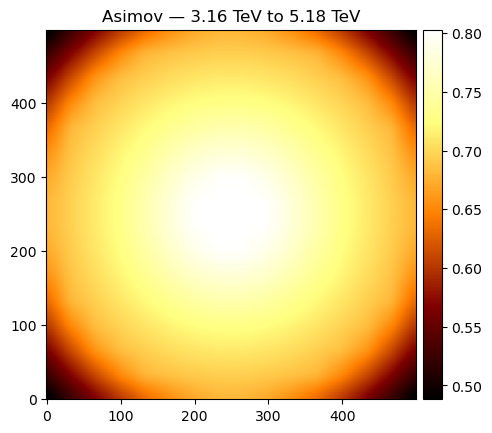

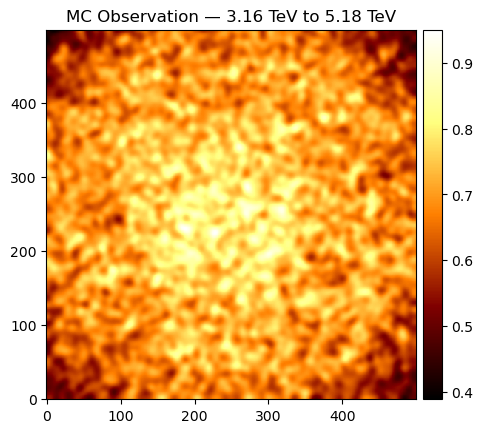

In [98]:
# Static comparison: restricted energy range
energy_min = 3.16 * u.TeV
energy_max = 5.18 * u.TeV
energy_axis = dataset_asimov.counts.geom.axes["energy"]
energy_indices = np.where(
    (energy_axis.center >= energy_min) & (energy_axis.center <= energy_max)
)[0]

geom_image = dataset_asimov.counts.geom.to_image()

for ds, label in [(dataset_asimov, "Asimov"), (dataset_mc, "MC Observation")]:
    counts_sum = ds.counts.data[energy_indices, :, :].sum(axis=0)
    counts_map = WcsNDMap(geom=geom_image, data=counts_sum)
    smoothed_map = counts_map.smooth(0.05 * u.deg)

    fig, ax = plt.subplots()
    smoothed_map.plot(ax=ax, add_cbar=True)
    ax.set_title(f"{label} — {energy_min:.2f} to {energy_max:.2f}")
    plt.show()

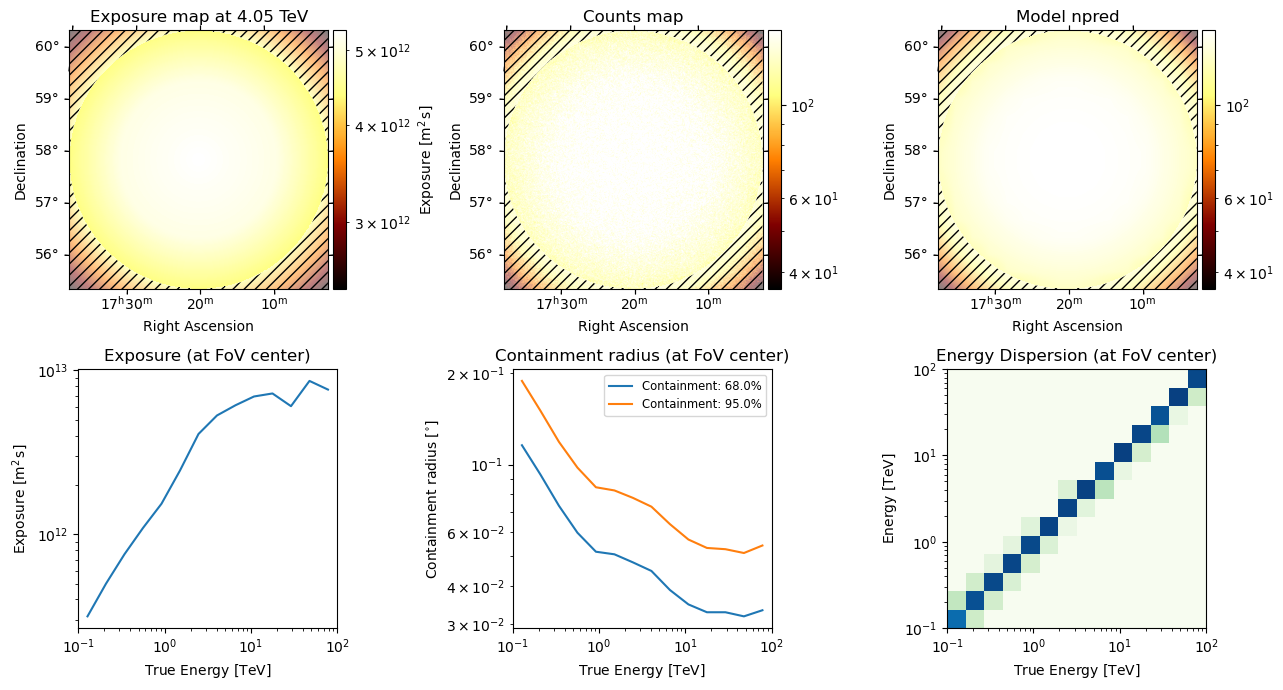

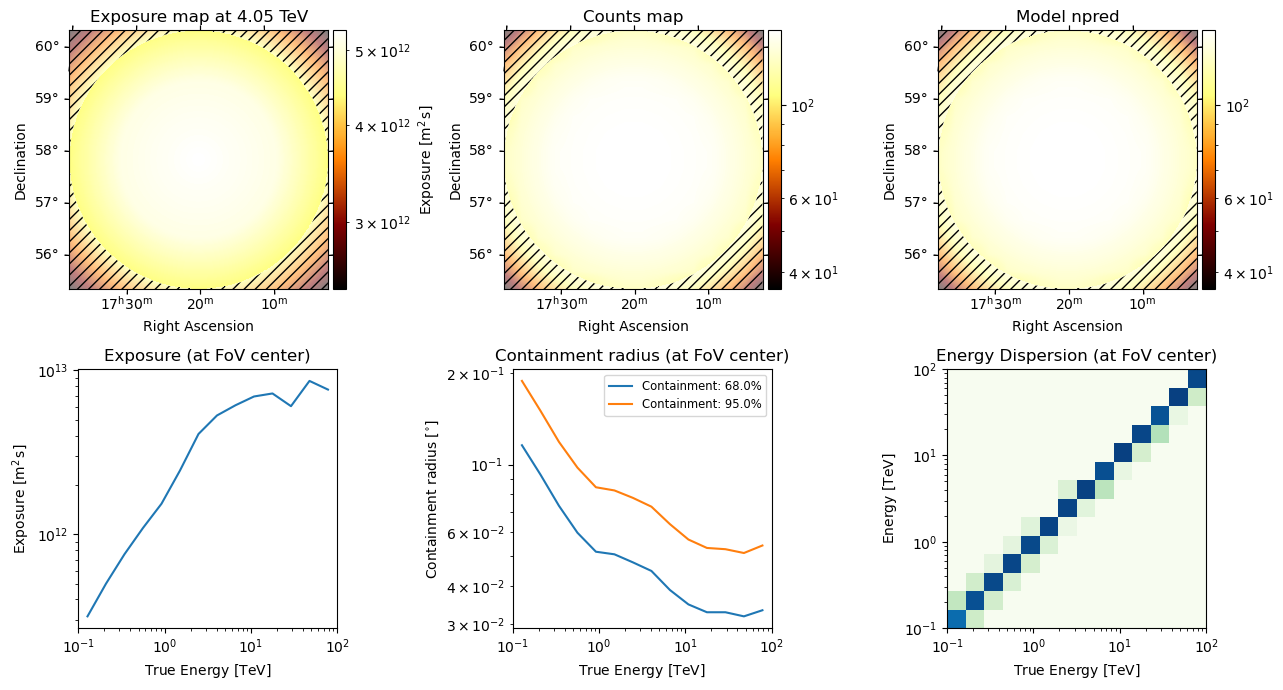

In [99]:
# Dataset inspection
dataset_mc.peek()
dataset_asimov.peek()

The figure summarizes the instrumental properties and the dataset fit: the top maps show the exposure, the observed counts, and the counts predicted by the model across the field of view; the bottom panels show how exposure, PSF containment radius (68% and 95%), and energy dispersion vary with energy, highlighting the improvement in angular and energy resolution at higher energies.

## Real Data management

When working with real telescope observations, the data arrive in **DL3 format** (check https://docs.gammapy.org/dev/user-guide/package.html for more detail about this data level): event lists and IRFs stored as FITS files, one per observation run. Instead of generating synthetic counts from a model, we load and reduce these files.

For this example, we will use the **H.E.S.S. DL3 DR1** public dataset included in `gammapy-data`. Although it covers the Crab Nebula rather than a dSph like in the simulations example, the reduction pipeline is identical — only the target coordinates and IRF choice would change for a real dSph analysis.

The reduction follows three steps:
1. **Load the data store** from the DL3 directory.
2. **Select observations** by target position.
3. **Run the makers** to bin the events into a `MapDataset`.

### 1. Loading the data

A `DataStore` points to a directory containing DL3 files organized according
to the GADF (Gamma-ray Astronomy Data Format) convention. From it we can
select observations by source position or observation ID.

In [100]:
from gammapy.data import DataStore

# Load the H.E.S.S. DL3 DR1 data store (included in gammapy-data)
data_store = DataStore.from_dir("$GAMMAPY_DATA/hess-dl3-dr1/")
print(data_store.obs_table[["OBS_ID", "RA_PNT", "DEC_PNT", "LIVETIME"]])

OBS_ID   RA_PNT   DEC_PNT    LIVETIME
          deg       deg         s    
------ --------- ---------- ---------
 20136  228.6125 -58.771667 1521.0269
 20137  228.6125 -59.771667  819.2054
 20151  228.6125 -58.771667  1530.479
 20275 187.27792   2.552389 1525.8447
 20282  228.6125 -58.771667 1543.3231
 20283  228.6125 -59.771667 1547.8253
 20301  228.6125 -58.771667 1534.0626
 20302  228.6125 -59.771667 1535.3478
 20303  228.6125 -58.771667 1535.1606
   ...       ...        ...       ...
 33798 329.71667 -30.725555 1572.3356
 33799 329.71667 -29.725555 1580.9498
 33800 329.13797 -30.225555 1591.7136
 33801 330.29538 -30.225555 1598.6652
 47802 330.29538 -30.225555 1572.4065
 47803 329.13797 -30.225555 1566.9369
 47804 329.71667 -29.725555 1560.2717
 47827 330.29538 -30.225555 1575.5515
 47828 329.13797 -30.225555 1562.4288
 47829 329.71667 -30.725555 1559.6072
Length = 105 rows


### 2. Observation selection

We select the observations pointing towards the Crab Nebula and set an interest radius regarding th source.

In [101]:
from astropy.coordinates import SkyCoord
import astropy.units as u

# Target coordinates
crab_pos = SkyCoord(ra=83.633 * u.deg, dec=22.014 * u.deg, frame="icrs")

# Select observations within a desired radius (2.5º in this case) of the Crab
selected_obs = data_store.get_observations(
    data_store.obs_table.select_sky_circle(
        center=crab_pos, radius=2.5 * u.deg
    )["OBS_ID"]
)

print(f"Number of selected observations: {len(selected_obs)}")

Number of selected observations: 4


### 3. Dataset reduction

We reuse the same `MapDatasetMaker` and `SafeMaskMaker` introduced in the simulation section — the *instrumental* part of the pipeline does not change when moving from simulated to real data. The only difference is that instead of a single synthetic `Observation`, we now have a collection of real observation runs, each with its own pointing, livetime, and IRFs.

In this case, like in the simulations section, we will follow a 3D approach, we manage the data using Spatail+Spectral data, rather than 1D, using only spectral. for more details about these aproaches check epigraph Dataset above, since the precedure is the same. Hence, the steps to follow are:

- **1. Geometry map.** We define a spatial+energy grid centered on the target, with a given pixel size and angular width, combined with the energy axis defined earlier. This geometry will hold the simulated counts, exposure, background, PSF, and energy dispersion.

- **2. Create an empty `MapDataset`**, using this geometry plus the true-energy axis needed for the IRFs. At this stage the dataset is just an empty container

    >**Note**. Since we are working wiht real data, we don't have to create the counts, but to compute it. to do so, we have to indicate the "counts" clasue to the maker, so they compute when running.

- **3. Set up the makers.** The `MapDatasetMaker` computes the instrumental ingredients — exposure, background, PSF, and energy dispersion — from the observation's IRFs. The `SafeMaskMaker` defines a "safe" region within the field of view where the IRFs are reliable — here we exclude pixels beyond 2.5° from the pointing direction, where the effective area drops sharply and the response becomes poorly constrained.

- **4. Run the makers and attach the models.** `maker.run()` fills the empty dataset with the instrumental quantities, and `maker_safe_mask.run()` applies the safe mask on top. Finally, we attach our physics models — the dark matter signal (`model_simu`) and the background model (`bkg_model`) — so the dataset knows what to predict when we later call `npred()`.




MapDataset
----------

  Name                            : dataset-real-crab 

  Total counts                    : 10159 
  Total background counts         : 6328.96
  Total excess counts             : 3830.04

  Predicted counts                : 6328.96
  Predicted background counts     : 6328.96
  Predicted excess counts         : nan

  Exposure min                    : 3.41e+06 m2 s
  Exposure max                    : 3.63e+09 m2 s

  Number of total bins            : 875000 
  Number of fit bins              : 812500 

  Fit statistic type              : cash
  Fit statistic value (-2 log(L)) : nan

  Number of models                : 0 
  Number of parameters            : 0
  Number of free parameters       : 0




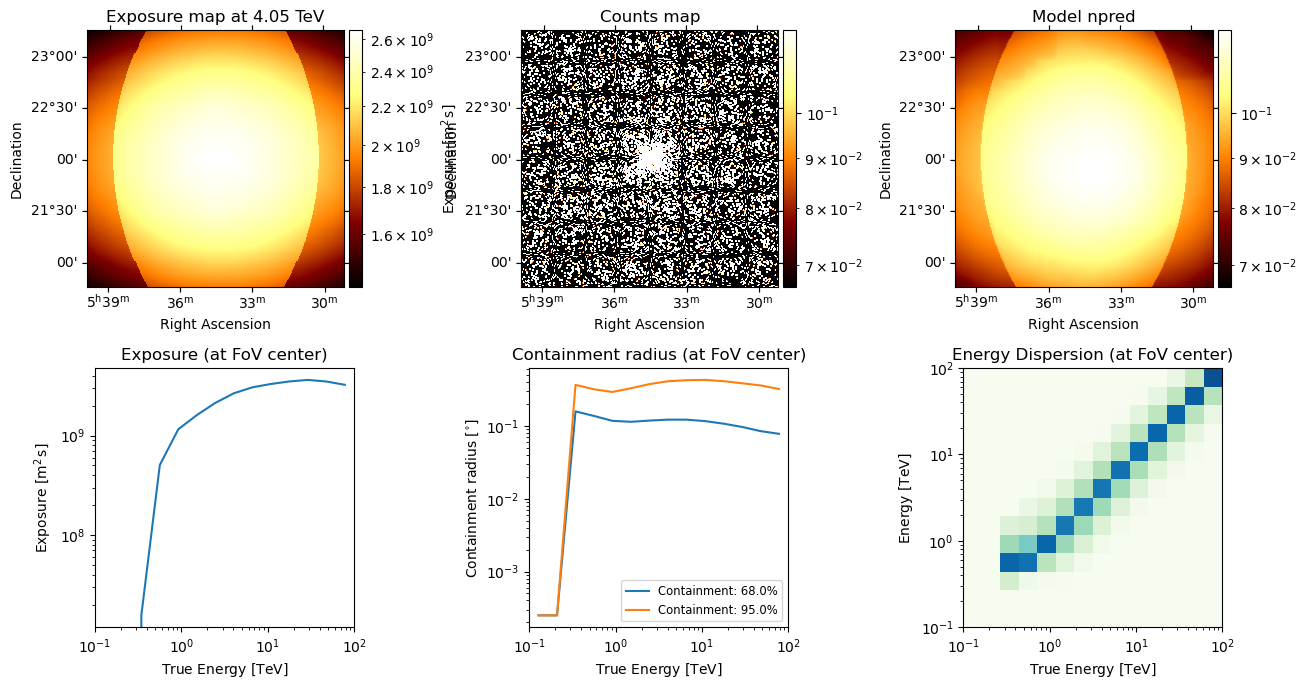

In [110]:
# Set energy bounds
energy_edges = np.logspace(-1, 2, 15)
# The reconstructed energy axis, used for the final map and counts (i.e. what the telescope measures).
energy_reco = MapAxis.from_edges(energy_edges, unit="TeV", name="energy", interp="log")
# The true energy axis, used internally for the IRFs (e.g. effective area, energy dispersion), since the instrument's response is defined in terms of the true photon energy before any reconstruction effects.
energy_true = MapAxis.from_edges(energy_edges, unit="TeV", name="energy_true", interp="log")

# Geometry map
geom_crab = WcsGeom.create(
    skydir=crab_pos, # Source position/map center
    binsz=0.01,# Pixel size
    width=2.5, # Width of our simulation geometry
    frame="icrs",
    axes=[energy_reco] # Energy axis of the map
)

# Create an empty MapDataset
empty = MapDataset.create(
    geom=geom_crab,
    name="dataset-real-crab",
    energy_axis_true=energy_true
)

# Setup Maker to calculate exposure, background, PSF, energy dispersion and COUNTS
maker = MapDatasetMaker(selection=["exposure", "background", "psf", "edisp", "counts"])

# Safe mask
maker_safe_mask = SafeMaskMaker(
    methods=["offset-max"],
    offset_max=2.5 * u.deg
    )

# Stack all runs
stacked = empty.copy(name="dataset-real-crab")

for obs in selected_obs:
    dataset = maker.run(empty.copy(), obs)
    dataset = maker_safe_mask.run(dataset, obs)
    stacked.stack(dataset)

print(stacked)
stacked.peek()

Unlike the simulated case, the counts map shows the sparse pattern typical of real data with low statistics.

### From real data to DM analysis

Unlike the simulation case — where the models had to be attached *before* generating the counts (since `npred()` was needed to create the Asimov or Monte Carlo data) — here the counts already exist: they came directly from the real events recorded when the maker ran. Attaching the model now serves a different purpose: telling Gammapy what hypothesis to compare against the data we already have.

The steps to build the signal and background models are exactly the same
ones described in the previous section (spatial model, spectral model, combined `SkyModel`, and `FoVBackgroundModel`).

It is noteworthy that even though we already have a background prediction from the IRFs, we attach a `FoVBackgroundModel` so that this prediction can be rescaled during the fit to match the real data, preventing any background mismatch from being absorbed into the dark matter signal.

Once this is done, the dataset is ready for likelihood fitting and upper limit computation, following the exact same procedure used in the simulated case.

In [113]:
# DM Spatial distribution

spatial_model = PointSpatialModel(
    lon_0=crab_pos.ra,
    lat_0=crab_pos.dec,
    frame="icrs"
)
# DM spectral distribution

# DM parameters: mass and channel
channel = "b"
massDM = 10 * u.TeV


# NOTE: this is a placeholder value for illustration only.
# The Crab Nebula is NOT a dark matter target; a real J-factor
# would only apply to a DM-dominated source.
jfact_crab = 1.66e23 * u.GeV**2 / u.cm**5

spectral_model = DarkMatterAnnihilationSpectralModel(
    mass=massDM, channel=channel, jfactor=jfact_crab)

# Combined model
sky_model = SkyModel(
    spatial_model=spatial_model,
    spectral_model=spectral_model,
    name="crab-dm"
)

bkg_model = FoVBackgroundModel(dataset_name=stacked.name)

# Attach the DM model and a Field-of-View background model
stacked.models = Models([sky_model, bkg_model])


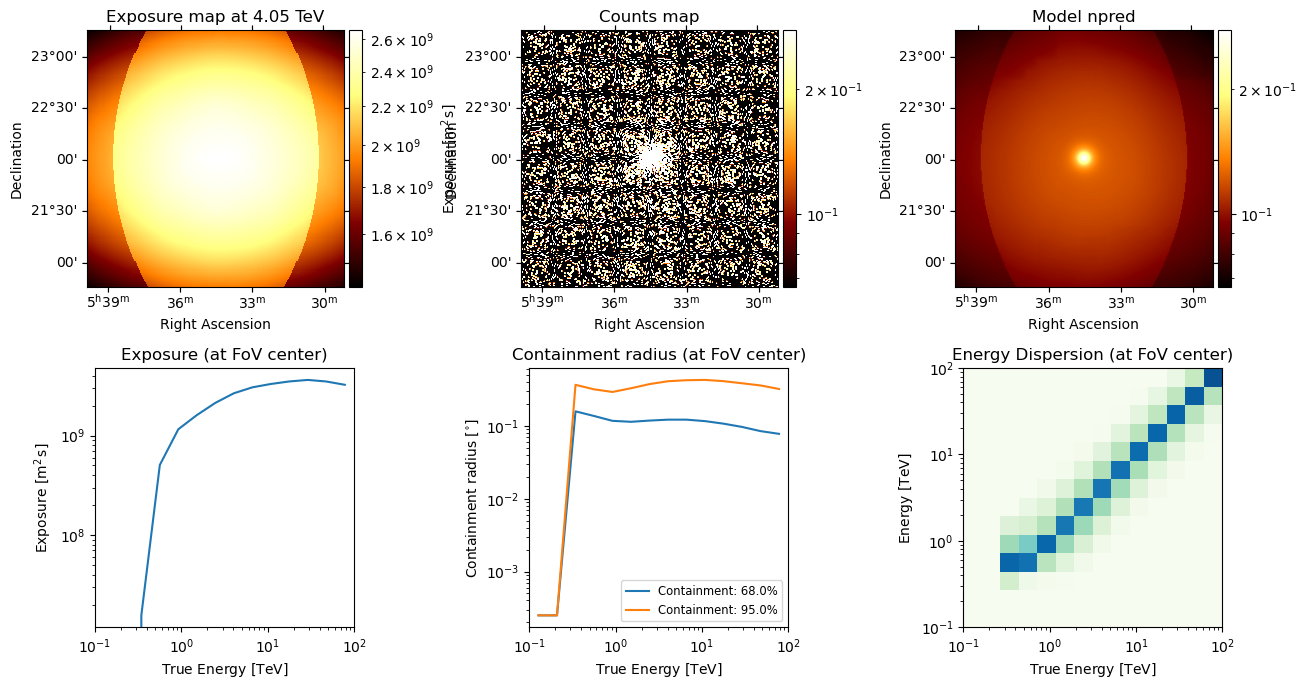

In [114]:
# Dataset inspection
# In the exposure map we can see the convergence between the different runs
stacked.peek()

In the previous case, only the field-of-view background model was fitted, so `Model npred` was smooth and lacked any central peak — it reflected the background level alone, without capturing Crab's point-like excess. Now, with the point-source dark matter model added alongside the background component, `Model npred` combines both contributions and correctly reproduces the central peak seen in the counts map.

## Data inspection

Before proceeding to the statistical analysis, it is good practice to visually inspect the simulated datasets. This allows us to verify that the simulation is physically reasonable and that the signal is visible above the background.

As eeen in previuos sections, the `peek()` method provides a quick overview of the dataset in a single figure. Additionally, here show these different visualization methods:

- **Interactive count map:** allows you to browse the spatial distribution of counts slice by slice in energy, which is useful for identifying
  where the signal contributes most.
- **Integrated count map:** the counts summed over all energy bins, giving a global view of the spatial morphology.
- **Energy-restricted count map:** counts integrated over a narrow energy window around the signal peak, where the DM signal-to-background ratio is highest.
- **Plots for checking the distribution of the signal, background and excess**

In all cases we compare the Asimov and MC datasets side by side. The Asimov
map is smooth by construction, while the MC map shows the pixel-to-pixel
Poisson fluctuations expected in a real observation.

In [ ]:
# Interactive
# You can change the energy range and the scale as you wish
stacked.counts.smooth(0.05 * u.deg).plot_interactive(add_cbar=True, stretch="linear")
plt.show()


interactive(children=(SelectionSlider(continuous_update=False, description='Select energy:', layout=Layout(wid…

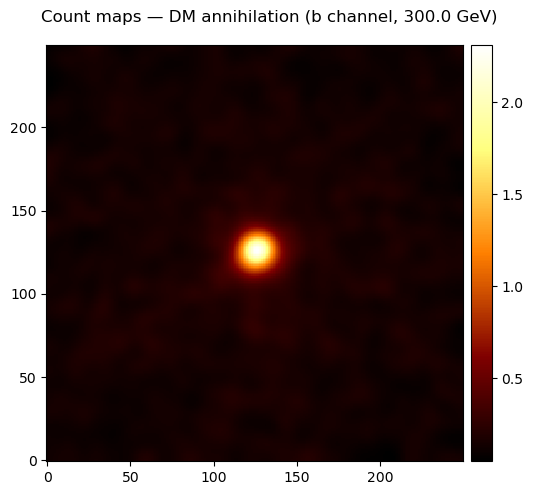

In [106]:
# Static : summed over all energies
fig, axes = plt.subplots(1, figsize=(12, 5))

stacked.counts.reduce_over_axes().smooth(0.05 * u.deg).plot(
    ax=axes, add_cbar=True
)

plt.suptitle(f"Count maps — DM annihilation ({channel} channel, {massDM})")
plt.tight_layout()
plt.show()


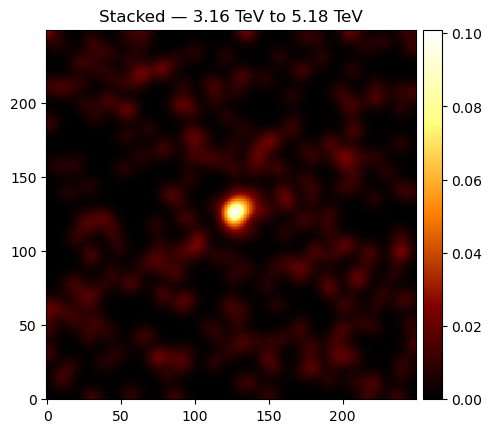

In [107]:
# Static comparison: restricted energy range
energy_min = 3.16 * u.TeV
energy_max = 5.18 * u.TeV
energy_axis = stacked.counts.geom.axes["energy"]
energy_indices = np.where(
    (energy_axis.center >= energy_min) & (energy_axis.center <= energy_max)
)[0]

geom_image = stacked.counts.geom.to_image()

counts_sum = stacked.counts.data[energy_indices, :, :].sum(axis=0)
counts_map = WcsNDMap(geom=geom_image, data=counts_sum)
smoothed_map = counts_map.smooth(0.05 * u.deg)

fig, ax = plt.subplots()
smoothed_map.plot(ax=ax, add_cbar=True)
ax.set_title(f"Stacked — {energy_min:.2f} to {energy_max:.2f}")
plt.show()

From the two plots above we can see that our data is concentrated in one point and has an approximately point-like shape.

[]

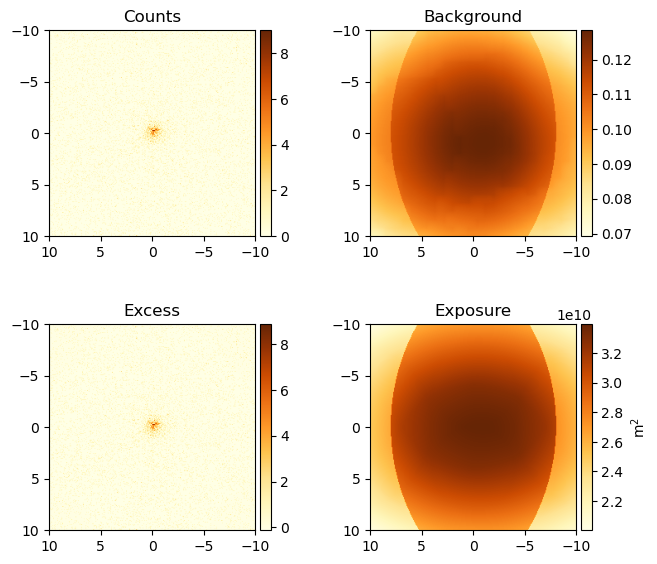

In [108]:
# Signal vs Background

fig_peek, axs = plt.subplots(2,2, figsize=(7,7))

img_1 = axs[0,0].imshow(
    np.sum(stacked.counts.data, axis=0),
    extent=(10.0+0.0,-10.0+0.0,10.0+0.0,-10.0+0.0),
    origin = 'lower',
    cmap='YlOrBr',
)
axs[0,0].set_title('Counts')
divider = make_axes_locatable(axs[0,0])
cax = divider.append_axes('right', size='5%', pad=0.05)
cbar_1 = fig_peek.colorbar(img_1, cax=cax, orientation='vertical')

img_2 = axs[0,1].imshow(
    np.sum(stacked.background.data, axis=0),
    extent=(10.0+0.0,-10.0+0.0,10.0+0.0,-10.0+0.0),
    origin = 'lower',
    cmap='YlOrBr'
)
axs[0,1].set_title('Background')
divider = make_axes_locatable(axs[0,1])
cax = divider.append_axes('right', size='5%', pad=0.05)
cbar_2 = fig_peek.colorbar(img_2, cax=cax, orientation='vertical')

img_3 = axs[1,0].imshow(
    np.sum(stacked.counts.data, axis=0) - np.sum(stacked.background.data, axis=0),
    extent=(10.0+0.0,-10.0+0.0,10.0+0.0,-10.0+0.0),
    origin = 'lower',
    cmap='YlOrBr'
)
axs[1,0].set_title('Excess')
divider = make_axes_locatable(axs[1,0])
cax = divider.append_axes('right', size='5%', pad=0.05)
cbar_3 = fig_peek.colorbar(img_3, cax=cax, orientation='vertical')

img_4 = axs[1,1].imshow(
    np.sum(stacked.exposure.data, axis=0),
    extent=(10.0+0.0,-10.0+0.0,10.0+0.0,-10.0+0.0),
    origin = 'lower',
    cmap='YlOrBr'
)
axs[1,1].set_title('Exposure')
divider = make_axes_locatable(axs[1,1])
cax = divider.append_axes('right', size='5%', pad=0.05)
cbar_4 = fig_peek.colorbar(img_4, cax=cax, orientation='vertical')
cbar_4.ax.set_ylabel(r'm$^2$')

fig_peek.subplots_adjust(wspace=0.45, hspace=0.2)

plt.plot()

This figure compares the observed counts, the estimated background, the resulting excess, and the exposure across the field of view, all summed over energy.

The **Counts** map shows the total observed events, with a clear point-like excess at the center corresponding to Crab. The **Background** map shows the smooth, FoV-dependent background prediction, peaking near the center of the camera and falling off toward the edges due to the acceptance of the instrument. Subtracting the two gives the **Excess** map, which isolates the source signal from the background: as expected, only the central point source remains visible, confirming that the background model accounts for essentially all counts away from Crab. Finally, the **Exposure** map shows the effective area × observation time across the FoV, following the same elliptical acceptance pattern as the background, since both are shaped by the instrument's field-of-view response.

[]

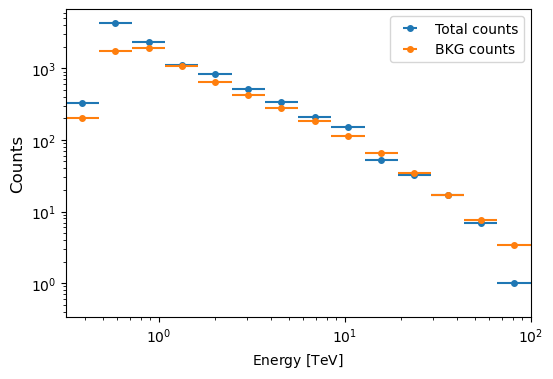

In [109]:
# Check the signal and background contributions
spec, axs = plt.subplots(1, 1, figsize=(6, 4))
stacked.counts.get_spectrum().plot(label='Total counts')
stacked.npred_background().get_spectrum().plot(label='BKG counts')

axs.set_ylabel('Counts', fontsize=12)
axs.legend()
plt.plot()

With this final plot is can be seen that the distribution of counts from signal and background are very similar in the plotted energy range.

## References

- Bonnivard, V. et al. 2015,*MNRAS*, 453, 849 — Dark matter annihilation and decay in dwarf spheroidal galaxies: The classical and ultrafaint dSphs. [arXiv:1504.02048](https://arxiv.org/abs/1504.02048)
- Bergström, L., Ullio, P., & Buckley, J.H. 1998, Astroparticle Physics, 9, 137–162. - Observability of gamma rays from dark matter neutralino annihilations in the Milky Way halo. [astro-ph/9712318](https://arxiv.org/abs/astro-ph/9712318)
- Cowan, G. et al. 2011, *EPJC*, 71, 1554— Asymptotic formulae for likelihood-based tests of new physics. [arXiv:1007.1727](https://arxiv.org/abs/1007.1727)